Let's explore more custom architectures for our model, an interesting idea could be trying to use higher resolutions.

Because our data is 512x512, taking advantage of all of the possible resolution to allow our CNN to see in finer detail could improve its performance:

A major limitation of standard CNN architectures is their input constraints. Deep learning models typically require high-resolution artwork to be aggressively down-sampled to tiny resolutions, such as 224x224 or 299x299 pixels, to accommodate GPU memory limits and standard network topologies. For fine art, this aggressive down-sampling is highly destructive. It completely obliterates the high-frequency details—the micro-textures of the canvas, the physical three-dimensional relief of the paint, and the individual bristles of the brushstrokes—which are often the most discriminative features for identifying specific artists or determining the authenticity of a style.

Imports and configure GPU

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings

import numpy as np
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

E0000 00:00:1775411149.362181    6557 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775411149.367745    6557 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775411149.382243    6557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775411149.382275    6557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775411149.382277    6557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775411149.382279    6557 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# 16GB Tesla T4 (Google Colab)
# 4GB RTX 3050 Ti Laptop (Afonso)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.7 * 1024))]
    )

Now let's import the data

Our goal now is to use the full resolution of the images to allow our model to identify finer details

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# DATA_PATH = "drive/MyDrive/Colab Notebooks/WikiArt/wikiart_datasets"

In [5]:
DATA_PATH = "../data"

image_size = (512, 512) # original image size
batch_size = 64
n_classes = 23

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=image_size,
    batch_size=batch_size,
    seed=255, # for reproducibility
    validation_split=0.2,
    subset="both",
    label_mode="categorical"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


I0000 00:00:1775411153.926347    6557 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3789 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
custom_model1 = keras.Sequential()

custom_model1.add(keras.Input(shape=image_size + (3,)))

custom_model1.add(layers.RandAugment())
custom_model1.add(layers.Rescaling(1./255))

# use bigger kernel size and stride to reduce agressively the dimensions
custom_model1.add(layers.Conv2D(32, 5, strides=2, activation="relu"))
custom_model1.add(layers.Conv2D(32, 3, activation="relu"))
custom_model1.add(layers.MaxPooling2D(3))

custom_model1.add(layers.Conv2D(32, 5, strides=2, activation="relu"))
custom_model1.add(layers.Conv2D(32, 3, activation="relu"))
custom_model1.add(layers.Conv2D(32, 3, activation="relu"))
custom_model1.add(layers.MaxPooling2D(3))

custom_model1.add(layers.Conv2D(32, 3, activation="relu"))
custom_model1.add(layers.Conv2D(32, 3, activation="relu"))
custom_model1.add(layers.MaxPooling2D(2))

custom_model1.add(layers.Flatten())

custom_model1.add(layers.Dense(256, activation="relu"))
custom_model1.add(layers.Dense(n_classes, activation="softmax"))

custom_model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rand_augment (RandAugment)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 252, 252, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 84, 84, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 38, 38, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 36, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,543 (826.34 KB)

 Trainable params: 211,543 (826.34 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
custom_model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [9]:
custom_model1_history = custom_model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/30


I0000 00:00:1775411170.816853    6687 cuda_dnn.cc:529] Loaded cuDNN version 91002


167/167 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - auc: 0.5108 - categorical_accuracy: 0.0948 - f1_score: 0.0369 - loss: 3.0611 - val_auc: 0.5500 - val_categorical_accuracy: 0.1094 - val_f1_score: 0.0384 - val_loss: 3.0327
Epoch 2/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - auc: 0.5461 - categorical_accuracy: 0.1075 - f1_score: 0.0392 - loss: 3.0276 - val_auc: 0.6412 - val_categorical_accuracy: 0.1409 - val_f1_score: 0.0584 - val_loss: 2.9744
Epoch 3/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - auc: 0.6183 - categorical_accuracy: 0.1334 - f1_score: 0.0748 - loss: 2.9383 - val_auc: 0.7040 - val_categorical_accuracy: 0.1893 - val_f1_score: 0.1040 - val_loss: 2.7838
Epoch 4/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - auc: 0.6588 - categorical_accuracy: 0.1549 - f1_score: 0.1009 - loss: 2.8545 - val_auc: 0.7329 - val_categorical_accuracy: 0.2181 - val_f1_score: 0.1369 - val_loss: 2.6787
Epoch 5/30
167/167 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - auc: 0.6852 - categorical_accuracy: 0.1728 - f1_

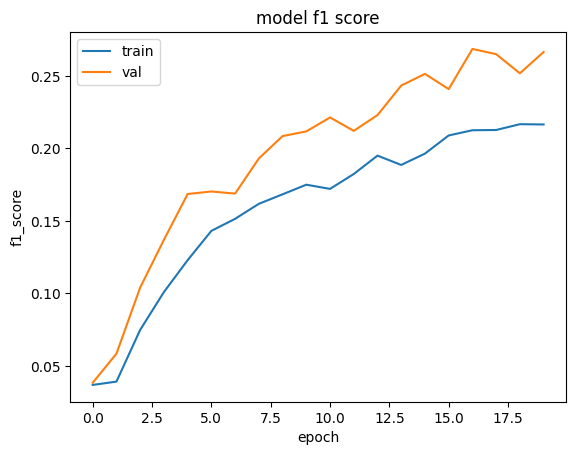

In [10]:
plt.plot(custom_model1_history.history['f1_score'])
plt.plot(custom_model1_history.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['train', 'val', ], loc='upper left')
plt.show()

In [11]:
epochs = range(len(custom_model1_history.history['val_f1_score']))

# val f1 score follows a log shape, so we need to log the independent 
# variable x to transform into a linear relation and apply linear regression
z = np.polyfit(np.log1p(epochs), custom_model1_history.history['val_f1_score'], 1)
p = np.poly1d(z)

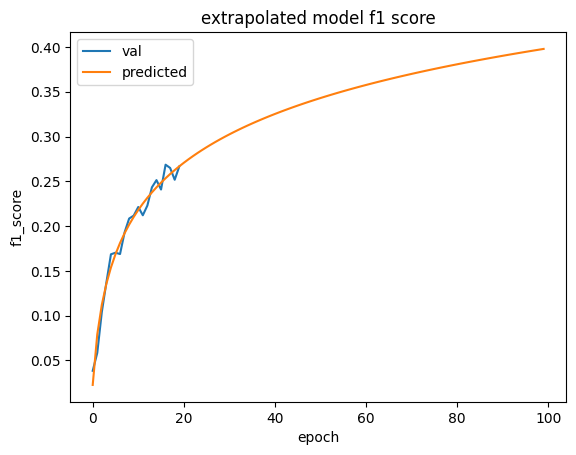

In [13]:
plt.plot(custom_model1_history.history['val_f1_score'])
plt.plot(p(np.log1p(range(100))))
plt.title('extrapolated model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['val', 'predicted'], loc='upper left')
plt.show()

The extrapolated performance seems to be similar to our last model, but it takes more time to train despite having less parameters (211k vs 384k)

Let's try a much bigger model, with much more parameters

In [37]:
custom_model2 = keras.Sequential()

custom_model2.add(keras.Input(shape=image_size + (3,)))

custom_model2.add(layers.RandAugment())
custom_model2.add(layers.Rescaling(1./255))

# use bigger kernel size and stride to reduce agressively the dimensions
custom_model2.add(layers.Conv2D(64, 5, strides=2, activation="relu"))
custom_model2.add(layers.Conv2D(64, 3, activation="relu"))
custom_model2.add(layers.MaxPooling2D(3))

custom_model2.add(layers.Conv2D(128, 5, strides=2, activation="relu"))
custom_model2.add(layers.Conv2D(128, 3, activation="relu"))
custom_model2.add(layers.Conv2D(128, 3, activation="relu"))
custom_model2.add(layers.MaxPooling2D(3))

custom_model2.add(layers.Conv2D(256, 3, activation="relu"))
custom_model2.add(layers.Conv2D(256, 3, activation="relu"))
custom_model2.add(layers.MaxPooling2D(2))

custom_model2.add(layers.Flatten())

custom_model2.add(layers.Dense(256, activation="relu"))
custom_model2.add(layers.Dense(n_classes, activation="softmax"))

custom_model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rand_augment_5 (RandAugment)    │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 254, 254, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 252, 252, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 84, 84, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 40, 40, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 38, 38, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 36, 36, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481,879 (9.47 MB)

 Trainable params: 2,481,879 (9.47 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
custom_model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # try a bigger learning rate for this much bigger model
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [39]:
custom_model2_history = custom_model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    # callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 269s 198ms/step - auc_6: 0.5444 - categorical_accuracy: 0.1078 - f1_score: 0.0481 - loss: 3.0313 - val_auc_6: 0.6033 - val_categorical_accuracy: 0.1083 - val_f1_score: 0.0497 - val_loss: 3.0292
Epoch 2/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 275s 206ms/step - auc_6: 0.6411 - categorical_accuracy: 0.1556 - f1_score: 0.0943 - loss: 2.8710 - val_auc_6: 0.7328 - val_categorical_accuracy: 0.2009 - val_f1_score: 0.0996 - val_loss: 2.6930
Epoch 3/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 267s 200ms/step - auc_6: 0.7147 - categorical_accuracy: 0.1992 - f1_score: 0.1450 - loss: 2.7049 - val_auc_6: 0.7930 - val_categorical_accuracy: 0.2324 - val_f1_score: 0.1519 - val_loss: 2.5022
Epoch 4/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 267s 200ms/step - auc_6: 0.7471 - categorical_accuracy: 0.2186 - f1_score: 0.1745 - loss: 2.6089 - val_auc_6: 0.8012 - val_categorical_accuracy: 0.2661 - val_f1_score: 0.1951 - val_loss: 2.4800
Epoch 5/10
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 267s 200ms/ste

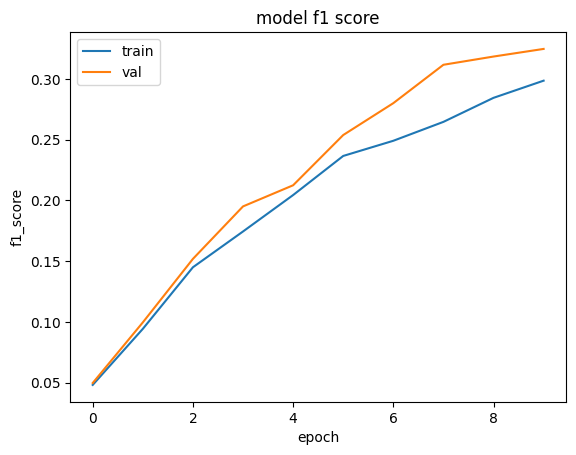

In [40]:
plt.plot(custom_model2_history.history['f1_score'])
plt.plot(custom_model2_history.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['train', 'val', ], loc='upper left')
plt.show()

In [41]:
epochs = range(len(custom_model2_history.history['val_f1_score']))

# val f1 score follows a log shape, so we need to log the independent 
# variable x to transform into a linear relation and apply linear regression
z = np.polyfit(np.log1p(epochs), custom_model2_history.history['val_f1_score'], 1)
p = np.poly1d(z)

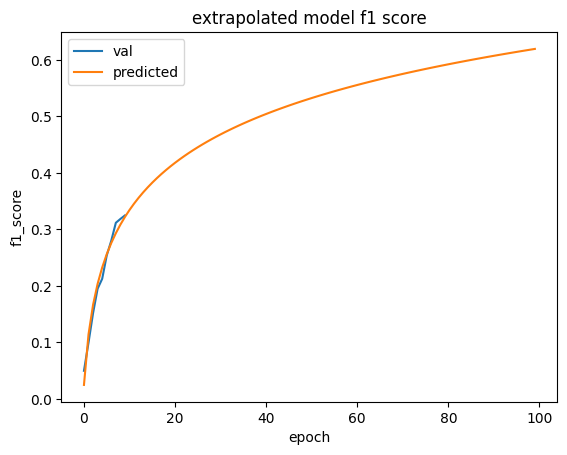

In [42]:
plt.plot(custom_model2_history.history['val_f1_score'])
plt.plot(p(np.log1p(range(100))))
plt.title('extrapolated model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['val', 'predicted'], loc='upper left')
plt.show()

The extrapolated performance after 100 epochs would now be about a little above 0.6 f1 score

Considering that each epoch would take 270s:

In [43]:
import datetime
str(datetime.timedelta(seconds=270*100))

'7:30:00'

It would take 7h30 to train this model, a bit less than the model from the previous notebook, but still a long time

Now let's add one dropout layer to the model